# Event Study
Compute CARs and run t-tests.

Event Study Results (t-tests on CAR):
--------------------------------------------------

One-Sample:
  Purchases:
    Mean CAR: -0.0496
    t-stat: -2.3306
    p-val: 0.0281
    95% CI: (-0.0935, -0.0058)
  Sales:
    Mean CAR: -0.0242
    t-stat: -19.4259
    p-val: 0.0000
    95% CI: (-0.0267, -0.0218)

Two-Sample (Welch):
  t-stat: -1.1909
  p-val: 0.2448

Wilcoxon:
  Purchases:
    w-stat: 101.0000
    p-val: 0.0585
  Sales:
    w-stat: 1392158.0000
    p-val: 0.0000
--------------------------------------------------


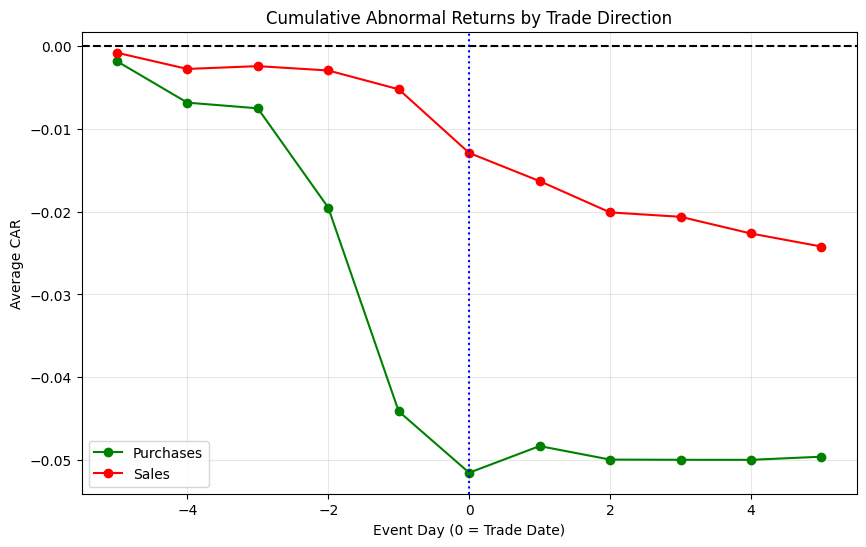

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
import event_study

# Load data
events_df = pd.read_csv('../data/processed/events_with_market_model.csv')
events_df['TRANS_DATE'] = pd.to_datetime(events_df['TRANS_DATE'])
prices = pd.read_csv('../data/processed/stock_prices.csv', index_col='Date', parse_dates=True)
benchmark = pd.read_csv('../data/processed/market_benchmark.csv', index_col='Date', parse_dates=True)

firm_returns = prices.pct_change().dropna()
market_col = '^GSPC' if '^GSPC' in benchmark.columns else benchmark.columns[0]
market_returns = benchmark[market_col].pct_change().dropna()

cars = []
cars_by_day = []

for idx, row in events_df.iterrows():
    ticker = row['ISSUERTRADINGSYMBOL']
    event_date = row['TRANS_DATE']
    alpha = row['alpha']
    beta = row['beta']

    if ticker not in firm_returns.columns:
        cars.append(np.nan)
        cars_by_day.append(np.full(11, np.nan))
        continue

    f_ret = firm_returns[ticker]
    ar = event_study.compute_abnormal_returns(f_ret, market_returns, event_date, alpha, beta, event_window=(-5, 5))

    if ar is not None and len(ar) == 11:
        cars.append(ar.sum())
        cars_by_day.append(ar.values)
    else:
        cars.append(np.nan)
        cars_by_day.append(np.full(11, np.nan))

events_df['CAR'] = cars
events_df['CAR_path'] = list(cars_by_day)
events_df = events_df.dropna(subset=['CAR'])

# Split by Purchase / Sale
purchases_df = events_df[events_df['TRANS_CODE'] == 'P']
sales_df = events_df[events_df['TRANS_CODE'] == 'S']

purchases = purchases_df['CAR']
sales = sales_df['CAR']

# Run tests
results = event_study.run_event_study_tests(purchases, sales)
print("Event Study Results (t-tests on CAR):")
print("-" * 50)
for test, stats in results.items():
    print(f"\n{test}:")
    for group, metrics in stats.items():
        if isinstance(metrics, dict):
            print(f"  {group}:")
            for k, v in metrics.items():
                if isinstance(v, tuple):
                    print(f"    {k}: ({v[0]:.4f}, {v[1]:.4f})")
                else:
                    print(f"    {k}: {v:.4f}")
        else:
            print(f"  {group}: {metrics:.4f}")
print("-" * 50)

# Plot Average CAR splitting by Purchase and Sale
plt.figure(figsize=(10,6))

if len(purchases_df) > 0:
    p_paths = np.vstack(purchases_df['CAR_path'].values)
    mean_p_ar = np.nanmean(p_paths, axis=0)
    mean_p_car = np.cumsum(mean_p_ar)
    plt.plot(range(-5, 6), mean_p_car, marker='o', label='Purchases', color='green')

if len(sales_df) > 0:
    s_paths = np.vstack(sales_df['CAR_path'].values)
    mean_s_ar = np.nanmean(s_paths, axis=0)
    mean_s_car = np.cumsum(mean_s_ar)
    plt.plot(range(-5, 6), mean_s_car, marker='o', label='Sales', color='red')

plt.title('Cumulative Abnormal Returns by Trade Direction')
plt.xlabel('Event Day (0 = Trade Date)')
plt.ylabel('Average CAR')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='blue', linestyle=':')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../report/car_plot.png')
plt.show()

# Drop CAR_path before saving to csv to keep it clean
events_df.drop(columns=['CAR_path']).to_csv('../data/processed/events_with_car.csv', index=False)
